# Deformable DEtection TRansformer（Deformable DETR）目标检测模型

> **论文**：*Deformable DETR: Deformable Transformers for End-to-End Object Detection*（Zhu et al., SenseTime & CUHK, 2021）
>
> **核心思想**：在 DETR 基础上引入**可变形注意力机制**（Deformable Attention），每个查询仅在参考点附近稀疏采样少量关键位置，而非关注全局所有 Token，从根本上解决 DETR 训练收敛慢、小目标检测弱的问题。
>
> **创新特性**：结合多尺度特征图（Multi-Scale Feature Map）与可变形采样，在保持端到端检测优势的同时，训练轮次从 DETR 的 500 epoch 大幅缩短至 **50 epoch**，小目标性能显著提升。

> ### 经典 Transformer 注意力 vs 可变形注意力
>
> | | 经典注意力 | 可变形注意力 |
> |---|---|---|
> | 计算范围 | 全局所有位置 | 参考点附近少量采样点 |
> | 计算复杂度 | $O\bigl((HW)^2\bigr)$ | $O(HW \cdot K)$，$K$ 为采样点数 |
> | 收敛速度 | 慢（需 500 epoch） | 快（约 50 epoch） |
>
> **经典注意力**计算方式：
>
> $$\text{score} = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d}}\right), \quad \text{output} = \text{score} \cdot V$$
>
> **可变形注意力**：Query 预测少量采样偏移量，仅在参考点附近聚合特征，大幅降低计算量。
>
> ![可变形注意力机制示意图](https://foruda.gitee.com/images/1721673147889889358/8dfbbbe4_5218658.png)

> ### `input_spatial_shapes` 的作用
>
> 在可变形注意力中，`input_spatial_shapes` 用于将采样**偏移量归一化**到 $[0,1]$ 坐标系，确保采样点不超出特征图范围。
>
> **归一化公式**：
>
> $$\text{sampling\_location} = \text{reference\_point} + \frac{\text{offset}}{\text{input\_spatial\_shapes}}$$
>
> | 维度 | 含义 | 示例 |
> |---|---|---|
> | 一维序列 | 序列长度 $L$ | `[8, 1]` |
> | 二维特征图 | 高 $H$、宽 $W$ | `[H, W]` |
>
> 1. **偏移量归一化**：避免采样点超出特征图边界，保证模型稳定性。
> 2. **空间坐标映射**：将像素单位偏移转换为 `grid_sample` 所需的归一化坐标。
> 3. **多尺度支持**：不同尺度特征图使用各自的 `spatial_shapes`，统一坐标空间。

## 一、环境准备

In [1]:
import seaborn as sns  # 导入 seaborn 可视化库，基于 matplotlib，提供更美观的统计图表接口
import numpy as np     # 导入 NumPy，提供高性能多维数组及矩阵运算支持，常与 PyTorch 配合使用

## 二、注意力机制对比实现（1D 演示）

In [ ]:
import torch                        # 导入 PyTorch，提供张量计算与自动微分
import torch.nn as nn               # 导入神经网络模块，提供 Module、Linear 等基础层
import torch.nn.functional as F     # 导入函数式 API，提供 softmax、grid_sample 等无状态函数

import matplotlib.pyplot as plt     # 导入 Matplotlib，用于绘制注意力热力图


class Attention(nn.Module):
    """
    经典 Transformer 自注意力机制（简化版：1D 单头，无 Q/K/V 投影）。

    计算流程：
        score = softmax(Q · Kᵀ / √d_hidden)
        output = score · V

    Args:
        hidden_size (int): 特征向量维度 d，默认 16。
    """

    def __init__(self, hidden_size: int = 16):
        super(Attention, self).__init__()    # 调用父类 nn.Module 的初始化方法
        self.hidden_size = hidden_size       # 保存隐层维度，用于缩放点积中的分母 √d

    def compute_score(self, q: torch.Tensor, k: torch.Tensor):
        """
        计算缩放点积注意力分数。

        Args:
            q (torch.Tensor): Query，形状 (batch_size, seq_len_q, hidden_size)。
            k (torch.Tensor): Key，形状 (batch_size, seq_len_k, hidden_size)。

        Returns:
            torch.Tensor: softmax 归一化后的注意力分数，
                形状 (batch_size, seq_len_q, seq_len_k)，每行和为 1。
        """
        # k.transpose(-2, -1): 转置最后两维，形状 (bs, hidden_size, seq_len_k)
        # torch.matmul: Q·Kᵀ 矩阵乘法，形状 (bs, seq_len_q, seq_len_k)
        # / self.hidden_size**0.5: 缩放，防止点积过大引发梯度消失
        score = torch.matmul(q, k.transpose(-2, -1)) / (self.hidden_size ** 0.5)
        # dim=-1: 沿 key 方向做 softmax，使每个 query 对所有 key 的权重和为 1
        return F.softmax(score, dim=-1)

    def forward(self, q: torch.Tensor, k: torch.Tensor, v: torch.Tensor):
        """
        前向传播：计算注意力输出。

        Args:
            q (torch.Tensor): Query，形状 (batch_size, seq_len_q, hidden_size)。
            k (torch.Tensor): Key，形状 (batch_size, seq_len_k, hidden_size)。
            v (torch.Tensor): Value，形状 (batch_size, seq_len_k, hidden_size)。

        Returns:
            Tuple[torch.Tensor, torch.Tensor]:
                - output: 注意力输出，形状 (batch_size, seq_len_q, hidden_size)。
                - score: 注意力权重矩阵，形状 (batch_size, seq_len_q, seq_len_k)。
        """
        # 计算缩放点积注意力分数，形状 (batch_size, seq_len_q, seq_len_k)
        score = self.compute_score(q, k)

        # 用分数对 Value 加权求和：score·V，形状 (batch_size, seq_len_q, hidden_size)
        output = torch.matmul(score, v)
        return output, score


class DeformableAttention(nn.Module):
    """
    可变形注意力机制（简化版 V1：1D 单头，无 Q/K/V 投影）。

    与经典注意力对全部位置计算权重不同，可变形注意力仅在
    参考点附近少量采样点上聚合特征，大幅降低计算复杂度。

    流程：
        Query → 线性层预测采样偏移量与注意力权重
        归一化采样位置 = 参考点 + 偏移量 / 特征图空间尺寸
        grid_sample(Value, 采样位置) → 各点特征
        加权求和 → 输出

    Args:
        hidden_size (int): 特征向量维度，默认 16。
        n_points (int): 每个参考点的采样点数量 K，默认 2。
    """

    def __init__(self, hidden_size: int = 16, n_points: int = 2):
        super().__init__()                          # 调用父类初始化
        self.hidden_size = hidden_size              # 保存隐层维度
        self.n_points = n_points                    # 保存采样点数量 K

        # 采样偏移量预测层：Query → (n_points × n_heads × 2D) 维偏移量
        # 本例 n_heads=1，2D 指 x/y 两个方向；输出形状 (bs, seq_len, n_points*2)
        self.sampling_offsets = nn.Linear(hidden_size, n_points * 1 * 2)

        # 注意力权重预测层：Query → (n_points × n_heads) 维权重
        # 本例 n_heads=1；输出形状 (bs, seq_len, n_points)
        self.attention_weights = nn.Linear(hidden_size, n_points * 1)

    def esitimate_offset_and_weights(self, q: torch.Tensor, reference_points: torch.Tensor):
        """
        通过可学习线性层从 Query 估计采样偏移量和注意力权重。

        Args:
            q (torch.Tensor): Query，形状 (batch_size, seq_len, hidden_size)。
            reference_points (torch.Tensor): 归一化参考点（[0,1]），
                形状 (batch_size, seq_len, 2)。

        Returns:
            Tuple[torch.Tensor, torch.Tensor]:
                - offset: 采样偏移量，形状 (batch_size, seq_len, n_points, 2)。
                - weights: softmax 归一化后的权重，形状 (batch_size, seq_len, n_points)。
        """
        # 线性层：q → 偏移量原始输出，形状 (bs, seq_len, n_points * 2)
        offset = self.sampling_offsets(q)

        # 线性层：q → 权重原始输出，形状 (bs, seq_len, n_points)
        weights = self.attention_weights(q)

        # 沿 n_points 维做 softmax，使各采样点权重之和为 1
        weights = F.softmax(weights, dim=-1)

        # 重塑偏移量，分离 x/y 两个方向：形状 (bs, seq_len, n_points, 2)
        return offset.reshape(q.shape[0], q.shape[1], self.n_points, 2), weights

    def ground_truth_offset_and_weights(self, q: torch.Tensor, reference_points: torch.Tensor):
        """
        手动构造 GT 采样偏移量和固定权重（仅用于演示，真实训练时不使用）。

        第 0 个采样点使用真实偏移（ground truth），其余随机；
        权重固定：第 0 点 0.8，其余均分 0.2。

        Args:
            q (torch.Tensor): Query，形状 (batch_size, seq_len, hidden_size)。
            reference_points (torch.Tensor): 归一化参考点，形状 (batch_size, seq_len, 2)。

        Returns:
            Tuple[torch.Tensor, torch.Tensor]:
                - offset: 形状 (batch_size, seq_len, n_points, 2)。
                - weights: 形状 (batch_size, seq_len, n_points)。
        """
        bs, seq_len, _ = q.shape             # 解包 batch_size 和序列长度

        # 随机初始化整数偏移量，范围 [0, seq_len)
        # 形状: (bs, seq_len, n_points, 2)，最后维表示 (x, y) 两个方向
        random_offset = torch.randint(0, seq_len, (bs, seq_len, self.n_points, 2))

        # 1D 序列无高度维，将所有采样点的 y 方向偏移置 0
        random_offset[:, :, :, 1] = 0.

        # 调整第 1 个采样点（索引 1）的 x 偏移：减去参考点绝对位置，使其变为相对偏移
        # reference_points[:, :, 0] * seq_len: 将归一化 x 坐标还原为绝对索引
        random_offset[:, :, 1, 0] = (
            random_offset[:, :, 1, 0] - reference_points[:, :, 0] * seq_len
        )

        # 计算第 0 个采样点的真实偏移：random_indexes 存储 GT 排列，作为对应关系的真值
        ground_truth_offset = random_indexes - reference_points[:, :, 0] * seq_len

        # 将真实偏移赋值给第 0 个采样点的 x 方向
        random_offset[:, :, 0, 0] = ground_truth_offset

        offset = random_offset              # 最终偏移量，形状 (bs, seq_len, n_points, 2)

        # 构造固定权重：第 0 个点（GT）权重 0.8，其余各点均分 0.2
        weights = torch.ones(offset.shape[:-1])       # 初始化全 1，形状 (bs, seq_len, n_points)
        weights[:, :, 0] = 0.8                        # GT 采样点权重
        weights[:, :, 1:] = 0.2 / (self.n_points - 1)  # 其余采样点均分

        return offset, weights

    def forward(self,
                q: torch.Tensor,
                v: torch.Tensor,
                reference_points: torch.Tensor,
                input_spatial_shapes: torch.Tensor,
                using_ground_truth: bool = False):
        """
        可变形注意力前向传播（V1）。

        Args:
            q (torch.Tensor): Query，形状 (batch_size, seq_len, hidden_size)。
            v (torch.Tensor): Value（骨干输出特征图），形状 (batch_size, seq_len, hidden_size)。
            reference_points (torch.Tensor): 归一化参考点（[0,1]），形状 (batch_size, seq_len, 2)。
            input_spatial_shapes (torch.Tensor): 特征图空间尺寸 (seq_len, 1)，用于偏移量归一化。
            using_ground_truth (bool): True 则使用手工 GT 偏移（演示），False 用线性层估计。

        Returns:
            Tuple[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]:
                - output: 注意力输出，形状 (batch_size, seq_len, hidden_size)。
                - (sampling_locations_absolute, weights): 绝对采样坐标与权重，用于可视化。
        """
        # 选择偏移量和权重的获取方式
        if using_ground_truth:
            sampling_offsets, weights = self.ground_truth_offset_and_weights(q, reference_points)
        else:
            sampling_offsets, weights = self.esitimate_offset_and_weights(q, reference_points)
        # sampling_offsets: (batch_size, seq_len, n_points, 2)
        # weights: (batch_size, seq_len, n_points)

        # 偏移量归一化因子：等于特征图空间尺寸 (seq_len, 1)
        # 将采样偏移从像素单位转换为 [0,1] 归一化坐标
        offset_normalizer = input_spatial_shapes

        # 计算归一化采样位置 = 参考点 + 归一化偏移量
        # reference_points[:, :, None, :]: (bs, seq_len, 1, 2) 广播到 n_points 维
        # offset_normalizer[None, None, None, :]: (1, 1, 1, 2) 广播除法
        # 结果 sampling_locations 形状: (bs, seq_len, n_points, 2)
        print(f'offset_normalizer.shape: {offset_normalizer[None, None, None, :].shape}')
        sampling_locations = (
            reference_points[:, :, None, :] +
            sampling_offsets / offset_normalizer[None, None, None, :]
        )
        print(f'sampling_locations.shape: {sampling_locations.shape}')

        # 将归一化坐标还原为绝对像素坐标，仅用于后续可视化
        # 形状: (bs, seq_len, n_points, 2)
        sampling_locations_absolute = sampling_locations * input_spatial_shapes[None, None, None, :]

        # 调整 Value 维度顺序，适配 grid_sample 输入格式
        # (bs, seq_len, hidden_size) → (bs, hidden_size, seq_len)
        v = v.permute(0, 2, 1)

        # 用 grid_sample 从 Value 中按采样位置插值取特征
        # v.unsqueeze(-1): (bs, hidden_size, seq_len, 1)，模拟 2D 特征图（高=seq_len，宽=1）
        # align_corners=True: 坐标 [-1,1] 精确对应输入边界像素中心
        # 输出 sampled_values 形状: (bs, hidden_size, seq_len, n_points)
        sampled_values = F.grid_sample(v.unsqueeze(-1), sampling_locations, align_corners=True)
        print(f'sampled_values.shape: {sampled_values.shape}')

        # 调整采样值维度以便与权重做逐元素乘法
        # (bs, hidden_size, seq_len, n_points) → (bs, seq_len, n_points, hidden_size)
        print(f'sampled_values.shape: {sampled_values.shape}')
        sampled_values = sampled_values.permute(0, 2, 3, 1)

        # 加权聚合各采样点特征
        # weights.unsqueeze(-1): (bs, seq_len, n_points, 1)，广播到 hidden_size 维度
        # torch.sum(..., dim=-2): 沿 n_points 维求和，形状 (bs, seq_len, hidden_size)
        output = torch.sum(sampled_values * weights.unsqueeze(-1), dim=-2)

        # 返回注意力输出和调试信息（绝对采样坐标与权重）
        return output, (sampling_locations_absolute, weights)


# ─── 演示数据准备 ─────────────────────────────────────────────────────────────

# Query：batch_size=1，序列长=8（每个位置一个查询向量），隐层维=16
# 形状: (1, 8, 16)，类型: torch.Tensor（float32）
dummy_query = torch.randn(1, 8, 16)

# Value：骨干网络（如 ResNet）输出的特征图，与 Query 形状相同
# 形状: (1, 8, 16)
dummy_value = torch.randn(1, 8, 16)

# 位置索引：记录序列中每个位置的原始下标，形状 (1, 8)，dtype=int64
indexes = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7]).unsqueeze(0)

# 随机置换：对 [0,7] 做随机洗牌，用于模拟 GT 对应关系，形状 (8,)
random_indexes = torch.randperm(8)
print("random_indexes", random_indexes)

# Key：将 Query 按随机索引重排，模拟与 Query 不同顺序的 Key 序列
# 形状: (1, 8, 16)
dummy_key = dummy_query[:, random_indexes]

# ─── 经典注意力推理 ──────────────────────────────────────────────────────────

attention = Attention()     # 实例化经典注意力，隐层维度=16

# 前向传播：Q·Kᵀ 缩放点积注意力
# output 形状: (1, 8, 16)；classic_score 形状: (1, 8, 8)
output, classic_score = attention(
    q=dummy_query,
    k=dummy_key,
    v=dummy_value
)

# ─── 可变形注意力推理 ────────────────────────────────────────────────────────

n_points = 3   # 每个参考点的采样点数量 K=3

deformable_attention = DeformableAttention(n_points=n_points)  # 实例化可变形注意力

# 构造均匀分布的参考点：序列中 8 个位置依次对应参考点，y 坐标恒为 0（1D 序列）
# reshape 前各行为 [x, y]；归一化到 [0,1]，参考点 x 坐标为 0/8, 1/8, ..., 7/8
# 形状: (1, 8, 2)
reference_points = torch.tensor([
    [0, 0], [1, 0], [2, 0], [3, 0],
    [4, 0], [5, 0], [6, 0], [7, 0]
]).reshape(1, 8, 2)         # (batch_size=1, seq_len=8, 2D(x,y))
reference_points = reference_points / 8   # 归一化到 [0, 1] 范围

# 可变形注意力前向推理（演示模式：使用 GT 偏移量）
# input_spatial_shapes=(8,1)：特征序列长度为 8，宽度维度为 1，用于偏移归一化
# output 形状: (1, 8, 16)；loc 形状: (1, 8, 3, 2)；deformable_score 形状: (1, 8, 3)
output, (loc, deformable_score) = deformable_attention(
    q=dummy_query,
    v=dummy_value,
    reference_points=reference_points,
    input_spatial_shapes=torch.tensor([8, 1]),
    using_ground_truth=True
)

# loc 的绝对坐标主要用于后续可视化注意力图
print("== deformable attention ==")
print("output shape", output.shape)          # 期望: (1, 8, 16)
print("deformable attention score shape", deformable_score.shape)  # 期望: (1, 8, 3)


random_indexes tensor([4, 6, 7, 3, 5, 0, 2, 1])
offset_normalizer.shape: torch.Size([1, 1, 1, 2])
sampling_locations.shape: torch.Size([1, 8, 3, 2])
sampled_values.shape: torch.Size([1, 16, 8, 3])
sampled_values.shape: torch.Size([1, 16, 8, 3])
== deformable attention ==
output shape torch.Size([1, 8, 16])
deformable attention score shape torch.Size([1, 8, 3])


## 三、grid_sample 函数演示

`torch.nn.functional.grid_sample` 是 PyTorch 中的一个函数，主要用于对图像或特征图进行采样和变换。它常用于图像处理、计算机视觉任务中，特别是在实现空间变换网络（Spatial Transformer Networks, STN）时。

> **核心作用**
>
> `grid_sample` 函数可以根据输入的采样网格 (`grid`) 对输入张量 (`input`) 进行采样，返回经过变换后的输出张量。它支持各种形式的空间变换，如仿射变换、透视变换等。

> **参数**
>
> - **input**: 输入张量，通常是 4D 张量，形状为 `(N, C, H, W)`，分别表示批次大小、通道数、高度和宽度。
> - **grid**: 采样网格，通常也是 4D 张量，形状为 `(N, H_out, W_out, 2)`，表示在输出空间中每个位置对应输入空间的位置。每个位置用一对坐标 (x, y) 来表示，其中 x 和 y 的范围是 [-1, 1]，分别对应输入图像的左上角和右下角。

> **工作原理**
>
> `grid_sample` 函数根据 `grid` 中的坐标，从 `input` 张量中采样相应的像素值。采样时可以选择不同的插值方式（例如双线性插值）和填充方式（例如边界填充或反射填充）。

> **主要选项**
>
> - **mode**: 插值模式，默认是 `'bilinear'`，可以选择 `'nearest'`（最近邻插值）或 `'bilinear'`（双线性插值）。
> - **padding_mode**: 当采样点落在输入范围之外时的填充模式。选项有 `'zeros'`（填充0）、 `'border'`（使用边界值填充）、`'reflection'`（反射填充）。
> - **align_corners**: 如果为 `True`，则 `grid` 的坐标对齐方式是角点对齐；如果为 `False`，则是中心点对齐。

> **示例**
>
> ```python
> import torch
> import torch.nn.functional as F
>
> # 创建一个示例输入张量
> input = torch.arange(1., 10.).view(1, 1, 3, 3)
>
> # 创建一个采样网格
> grid = torch.tensor([[[[-1, -1], [1, -1], [-1, 1], [1, 1]]]]).view(1, 2, 2, 2)
>
> # 应用 grid_sample
> output = F.grid_sample(input, grid, mode='bilinear', padding_mode='zeros', align_corners=True)
>
> print(output)
> ```

> **输出**
>
> ```plaintext
> tensor([[[[1., 3.],
>           [7., 9.]]]])
> ```

> **应用场景**
>
> - **图像变换**: `grid_sample` 常用于应用仿射变换、透视变换或其他空间变换。
> - **空间变换网络（STN）**: STN 是一种可以学习空间变换的网络结构，`grid_sample` 是其核心操作之一，用于根据变换参数生成变换后的图像或特征图。
>
> 通过 `grid_sample` 函数，你可以灵活地对图像或特征图进行采样和变换，帮助神经网络适应不同的视角或尺度变化。

In [3]:
# 构造 3×3 灰度特征图，像素值为 1~9 的连续浮点数
# view(1, 1, 3, 3): 形状 (N=1, C=1, H=3, W=3)，N=batch，C=channel，H=height，W=width
input = torch.arange(1., 10.).view(1, 1, 3, 3)
print(input)  # 输出: (1,1,3,3) 张量，值为 [[1,2,3],[4,5,6],[7,8,9]]

# 构造 2×2 采样网格，指定 4 个角点的坐标
# grid 坐标范围 [-1, 1]：x=-1 最左列，x=1 最右列；y=-1 最上行，y=1 最下行
# [-1,-1]→左上(值=1)，[1,-1]→右上(值=3)，[-1,1]→左下(值=7)，[1,1]→右下(值=9)
# view(1, 2, 2, 2): 形状 (N=1, H_out=2, W_out=2, 2)，最后维表示 (x, y)
# .float(): 转为 float32，满足 grid_sample 对 grid 类型的要求
grid = torch.tensor([[[[-1, -1], [1, -1]], [[-1, 1], [1, 1]]]]).view(1, 2, 2, 2).float()
print(grid)   # 输出: (1, 2, 2, 2) 坐标网格

# grid_sample：根据 grid 坐标从 input 中双线性插值采样
# mode='bilinear': 双线性插值（四角点正好在像素中心，结果等于最近邻）
# padding_mode='zeros': 超出边界坐标处填充 0
# align_corners=True: 坐标 ±1 精确对应输入图像的角点像素中心
# 输出形状: (N=1, C=1, H_out=2, W_out=2)
output = F.grid_sample(input, grid, mode='bilinear', padding_mode='zeros', align_corners=True)

print(output)  # 期望: tensor([[[[1., 3.], [7., 9.]]]])，对应四个角点像素值

tensor([[[[1., 2., 3.],
          [4., 5., 6.],
          [7., 8., 9.]]]])
tensor([[[[-1., -1.],
          [ 1., -1.]],

         [[-1.,  1.],
          [ 1.,  1.]]]])
tensor([[[[1., 3.],
          [7., 9.]]]])


## 四、注意力图可视化

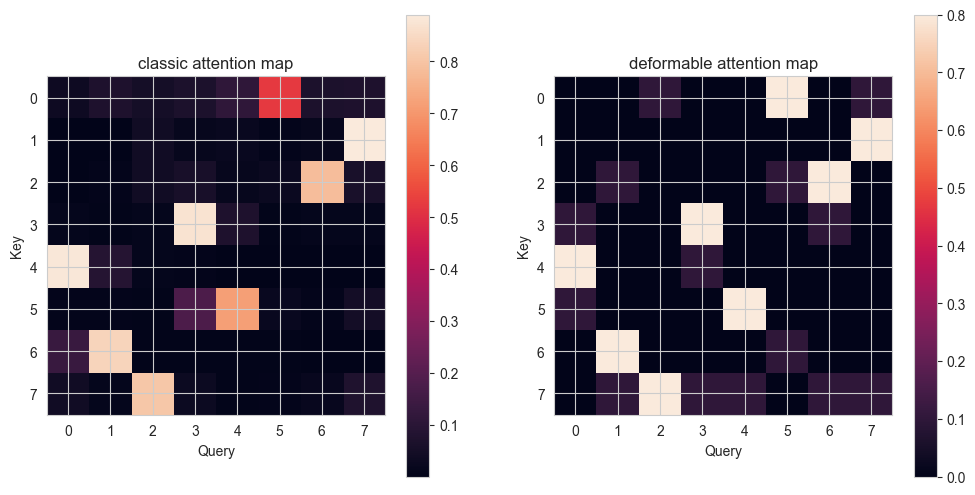

In [4]:
# loc: 可变形注意力的采样点绝对坐标，形状 (bs=1, seq_len=8, n_points=3, 2)
# 将稀疏采样权重"展开"回 8×8 密集矩阵，以便与经典注意力热力图对比

# 初始化全零的密集注意力矩阵
# 行=被关注的 key 位置（0~7），列=发出查询的 query 位置（0~7）
full_score = torch.zeros(8, 8)

for i in range(8):                           # 遍历每个 Query 位置（列）
    for j in range(n_points - 1, -1, -1):   # 逆序遍历 n_points 个采样点（后点先写，前点后覆盖）
        # 取第 i 个 Query、第 j 个采样点的 x 绝对坐标，四舍五入后截断到合法范围 [0, 7]
        # loc[0, i, j, 0]: 标量，float 类型；.item() 转为 Python float
        idx = max(0, min(7, int(loc[0, i, j, 0].item() + 0.5)))
        # 将该采样点的注意力权重写入密集矩阵对应位置
        # deformable_score[0, i, j]: 第 i 个 Query 对第 j 个采样点的权重，标量
        full_score[idx, i] = deformable_score[0, i, j].item()

# ─── 并排绘制两种注意力热力图 ─────────────────────────────────────────────────

plt.figure(figsize=(12, 6))    # 创建 12×6 英寸画布，左右各一张子图

# 左图：经典注意力（全局密集，每个 Query 对所有 Key 均有权重）
plt.subplot(1, 2, 1)                               # 选 1 行 2 列中的第 1 格
plt.imshow(classic_score[0], interpolation='nearest')  # classic_score[0] 形状 (8,8)，最近邻渲染
plt.colorbar()                                     # 添加颜色条，标示权重数值范围
plt.xlabel('Query')                                # x 轴标签：Query 位置索引
plt.ylabel('Key')                                  # y 轴标签：Key 位置索引
plt.title('classic attention map')                 # 子图标题

# 右图：可变形注意力（稀疏，每个 Query 仅有 n_points 个非零权重位置）
plt.subplot(1, 2, 2)                               # 选第 2 格
plt.imshow(full_score, interpolation='nearest')    # full_score 形状 (8,8)，大部分为 0
plt.colorbar()                                     # 添加颜色条
plt.xlabel('Query')                                # x 轴：Query 位置索引
plt.ylabel('Key')                                  # y 轴：被采样的 Key 位置索引
plt.title('deformable attention map')              # 子图标题

plt.show()    # 渲染并显示图像

## 五、可变形注意力完整实现（V2）

In [5]:
class DeformableAttention(nn.Module):
    """
    可变形注意力机制（完整实现版 V2：1D 单头，无 Q/K/V 投影）。

    在 V1 基础上精简代码，去除调试打印输出，
    可直接作为独立模块嵌入更大的模型（如 BEVFormer、Deformable DETR）。

    Args:
        hidden_size (int): 特征向量维度，默认 16。
        n_points (int): 每个参考点的采样点数量 K，默认 2。
    """

    def __init__(self, hidden_size: int = 16, n_points: int = 2):
        super(DeformableAttention, self).__init__()  # 调用父类初始化
        self.hidden_size = hidden_size               # 保存隐层维度
        self.n_points = n_points                     # 保存采样点数量 K

        # 偏移量预测线性层：Query → (n_points × n_heads × 2D) 维偏移量
        # 本例 n_heads=1，输出维度 = n_points * 2，形状 (bs, seq_len, n_points*2)
        self.sampling_offsets = nn.Linear(hidden_size, n_points * 1 * 2)

        # 注意力权重预测线性层：Query → n_points 维权重
        # 本例 n_heads=1，输出维度 = n_points，形状 (bs, seq_len, n_points)
        self.attention_weights = nn.Linear(hidden_size, n_points * 1)

    def esitimate_offset_and_weights(self, q: torch.Tensor, reference_points: torch.Tensor):
        """
        通过线性层从 Query 估计采样偏移量和注意力权重（真实训练流程）。

        Args:
            q (torch.Tensor): Query，形状 (batch_size, seq_len, hidden_size)。
            reference_points (torch.Tensor): 归一化参考点，形状 (batch_size, seq_len, 2)。

        Returns:
            Tuple[torch.Tensor, torch.Tensor]:
                - offset: 偏移量，形状 (batch_size, seq_len, n_points, 2)。
                - weights: softmax 归一化后的权重，形状 (batch_size, seq_len, n_points)。
        """
        # 线性变换预测偏移量，输出形状 (bs, seq_len, n_points * 2)
        offset = self.sampling_offsets(q)

        # 线性变换预测权重，输出形状 (bs, seq_len, n_points)
        weights = self.attention_weights(q)

        # dim=-1 方向 softmax，使 n_points 个权重之和为 1
        weights = F.softmax(weights, dim=-1)

        # 重塑偏移量，分离 x/y 两个方向：形状 (bs, seq_len, n_points, 2)
        return offset.reshape(q.shape[0], q.shape[1], self.n_points, 2), weights

    def ground_truth_offset_and_weights(self, q: torch.Tensor, reference_points: torch.Tensor):
        """
        手动构造 GT 偏移量和固定权重（仅用于演示，不参与训练）。

        Args:
            q (torch.Tensor): Query，形状 (batch_size, seq_len, hidden_size)。
            reference_points (torch.Tensor): 归一化参考点，形状 (batch_size, seq_len, 2)。

        Returns:
            Tuple[torch.Tensor, torch.Tensor]:
                - offset: 形状 (batch_size, seq_len, n_points, 2)。
                - weights: 形状 (batch_size, seq_len, n_points)。
        """
        bs, seq_len, _ = q.shape           # 解包 batch_size 和序列长度

        # 随机初始化整数偏移量，范围 [0, seq_len)
        # 形状: (bs, seq_len, n_points, 2)，最后维表示 (x, y)
        random_offset = torch.randint(0, seq_len, (bs, seq_len, self.n_points, 2))

        # 1D 序列无高度，y 方向偏移全部置 0
        random_offset[:, :, :, 1] = 0.

        # 调整第 1 个采样点的 x 偏移，使其相对于参考点绝对位置为相对偏移
        # reference_points[:, :, 0] * seq_len: 归一化 x 坐标 → 绝对像素索引
        random_offset[:, :, 1, 0] = (
            random_offset[:, :, 1, 0] - reference_points[:, :, 0] * seq_len
        )

        # 第 0 个采样点使用真实偏移：random_indexes 存储 GT 序列对应关系
        ground_truth_offset = random_indexes - reference_points[:, :, 0] * seq_len

        # 将 GT 偏移赋值给第 0 个采样点的 x 方向
        random_offset[:, :, 0, 0] = ground_truth_offset

        offset = random_offset             # 最终偏移量，形状 (bs, seq_len, n_points, 2)

        # 构造固定权重：第 0 个点（GT 点）权重 0.8，其余各点均分 0.2
        weights = torch.ones(offset.shape[:-1])        # 形状 (bs, seq_len, n_points)
        weights[:, :, 0] = 0.8                         # GT 采样点权重
        weights[:, :, 1:] = 0.2 / (self.n_points - 1)  # 其余点权重均分

        return offset, weights

    def forward(self,
                q: torch.Tensor,
                v: torch.Tensor,
                reference_points: torch.Tensor,
                input_spatial_shapes: torch.Tensor,
                using_ground_truth: bool = False):
        """
        可变形注意力前向传播（V2 简洁版）。

        Args:
            q (torch.Tensor): Query，形状 (batch_size, seq_len, hidden_size)。
            v (torch.Tensor): Value（骨干特征图），形状 (batch_size, seq_len, hidden_size)。
            reference_points (torch.Tensor): 归一化参考点，形状 (batch_size, seq_len, 2)。
            input_spatial_shapes (torch.Tensor): 特征图空间尺寸 (seq_len, 1)，用于偏移归一化。
            using_ground_truth (bool): True 使用手工 GT 偏移（演示），False 由线性层估计。

        Returns:
            Tuple[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]:
                - output: 可变形注意力输出，形状 (batch_size, seq_len, hidden_size)。
                - (sampling_locations_absolute, weights): 绝对采样坐标与权重，供可视化使用。
        """
        # 选择偏移量和权重的来源（GT 演示模式 or 线性层估计模式）
        if using_ground_truth:
            sampling_offsets, weights = self.ground_truth_offset_and_weights(q, reference_points)
        else:
            sampling_offsets, weights = self.esitimate_offset_and_weights(q, reference_points)
        # sampling_offsets: (bs, seq_len, n_points, 2)
        # weights: (bs, seq_len, n_points)

        # 偏移量归一化因子：等于特征图空间尺寸 (seq_len, 1)
        # 除以空间尺寸后，偏移量从像素单位转为 [0,1] 归一化坐标
        offset_normalizer = input_spatial_shapes

        # 计算归一化采样位置：参考点 + 归一化偏移量
        # reference_points[:, :, None, :]: (bs, seq_len, 1, 2)，None 增加 n_points 维度（广播）
        # 结果 sampling_locations 形状: (bs, seq_len, n_points, 2)，如 (1, 8, 3, 2)
        sampling_locations = (
            reference_points[:, :, None, :] +
            sampling_offsets / offset_normalizer[None, None, None, :]
        )

        # 将归一化坐标还原为绝对坐标（仅用于可视化，不参与梯度计算逻辑）
        # 形状: (bs, seq_len, n_points, 2)
        sampling_locations_absolute = (
            sampling_locations * input_spatial_shapes[None, None, None, :]
        )

        # 调整 Value 维度顺序，适配 grid_sample 输入格式
        # (bs, seq_len, hidden_size) → (bs, hidden_size, seq_len)
        v = v.permute(0, 2, 1)

        # 从 Value 中按采样位置双线性插值取特征
        # v.unsqueeze(-1): (bs, hidden_size, seq_len, 1)，模拟高=seq_len、宽=1 的 2D 特征图
        # align_corners=True: 坐标 ±1 对应输入图像角点像素中心
        # 输出 sampled_values 形状: (bs, hidden_size, seq_len, n_points)
        sampled_values = F.grid_sample(v.unsqueeze(-1), sampling_locations, align_corners=True)

        # 调整维度便于加权求和
        # (bs, hidden_size, seq_len, n_points) → (bs, seq_len, n_points, hidden_size)
        sampled_values = sampled_values.permute(0, 2, 3, 1)

        # 加权聚合各采样点特征
        # weights.unsqueeze(-1): (bs, seq_len, n_points, 1)，广播到 hidden_size
        # torch.sum(..., dim=-2): 沿 n_points 维求和，输出形状 (bs, seq_len, hidden_size)
        output = torch.sum(sampled_values * weights.unsqueeze(-1), dim=-2)

        return output, (sampling_locations_absolute, weights)


# ─── V2 演示：构造数据并运行可变形注意力 ──────────────────────────────────────

# 构造随机 Query（batch=1，序列长=8，维度=16），形状 (1, 8, 16)，float32
dummy_query = torch.randn(1, 8, 16)

# 构造随机 Value（与 Query 形状相同），代表骨干输出特征图，形状 (1, 8, 16)
dummy_value = torch.randn(1, 8, 16)

# 位置索引：记录每个序列位置的原始下标，形状 (1, 8)，dtype=int64
indexes = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7]).unsqueeze(0)

# 随机置换：用于 ground_truth_offset_and_weights 中的 GT 对应关系，形状 (8,)
random_indexes = torch.randperm(8)
print("random_indexes", random_indexes)

# Key 为 Query 的随机排列（保持接口与 V1 一致），形状 (1, 8, 16)
dummy_key = dummy_query[:, random_indexes]

# 实例化可变形注意力，采样点数 K=3
n_points = 3
deformable_attention = DeformableAttention(n_points=n_points)

# 构造均匀参考点：序列 8 个位置等间距，y 坐标恒为 0（1D 无高度维）
# 归一化到 [0,1]：参考点 x = 0/8, 1/8, ..., 7/8
# 形状: (1, 8, 2)
reference_points = torch.tensor([
    [0, 0], [1, 0], [2, 0], [3, 0],
    [4, 0], [5, 0], [6, 0], [7, 0]
]).reshape(1, 8, 2)
reference_points = reference_points / 8   # 归一化坐标范围 [0, 1]

# 前向推理（演示模式：使用手工构造的 GT 偏移量）
# output 形状: (1, 8, 16)；loc 形状: (1, 8, 3, 2)；deformable_score 形状: (1, 8, 3)
output, (loc, deformable_score) = deformable_attention(
    q=dummy_query,
    v=dummy_value,
    reference_points=reference_points,
    input_spatial_shapes=torch.tensor([8, 1]),
    using_ground_truth=True
)

# 打印输出形状以验证模型运行正确
print("== deformable attention ==")
print("output shape", output.shape)                        # 期望: (1, 8, 16)
print("deformable attention score shape", deformable_score.shape)  # 期望: (1, 8, 3)

random_indexes tensor([3, 2, 5, 7, 0, 4, 1, 6])
== deformable attention ==
output shape torch.Size([1, 8, 16])
deformable attention score shape torch.Size([1, 8, 3])


## 六、Hugging Face Deformable DETR 推理实验

### 6.1 加载预训练模型与图像处理器

In [1]:
import subprocess, sys                                                          # 用于在 notebook 内执行 pip 安装命令
# SenseTime/deformable-detr 的骨干网络（TimmBackbone）依赖 timm 库，需提前安装
# timm: PyTorch Image Models，提供 ResNet 等骨干网络的 timm 版本实现
subprocess.check_call([sys.executable, "-m", "pip", "install", "timm", "-q"])  # 若已安装则静默跳过

import os                                                                        # 操作系统接口，用于设置环境变量
from PIL import Image                                                          # PIL 图像库，用于打开和处理图像，返回 PIL.Image.Image 对象
import requests                                                                # HTTP 请求库，用于从 URL 流式下载图像
import torch                                                                   # PyTorch，提供张量计算与推理上下文管理
import matplotlib.pyplot as plt                                                # Matplotlib，用于渲染检测结果图
import matplotlib.patches as patches                                           # Matplotlib 图形 patch，提供矩形框绘制
from transformers import AutoImageProcessor, DeformableDetrForObjectDetection  # HF Transformers Deformable DETR 组件

# SenseTime/deformable-detr 未在 ModelScope 上发布，改用 HuggingFace 镜像站（hf-mirror.com）加速国内下载
# HF_ENDPOINT 环境变量会被 transformers 的 from_pretrained 自动读取，
# 将所有 HuggingFace 请求重定向到镜像服务器，无需修改其余代码
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"  # str，HF 镜像站地址，国内访问速度接近 ModelScope

# 预训练模型标识符：SenseTime 官方 Deformable DETR，在 COCO 2017 上预训练，AP≈44.5（50 epoch）
# 相比普通 DETR（AP≈42.0，500 epoch），收敛速度快 10 倍且精度更高
MODEL_NAME = "SenseTime/deformable-detr"  # str，HuggingFace Hub 上的模型 id

# Windows 下 from_pretrained 默认使用符号链接缓存文件，会触发 WinError 1314（权限不足）
# 解决方案：用 snapshot_download(local_dir=...) 直接复制文件到本地目录，绕过符号链接，
# 再从本地目录调用 from_pretrained，无需额外权限
from huggingface_hub import snapshot_download  # HF Hub 下载工具，local_dir 模式直接复制文件，不创建 symlink

# MODEL_LOCAL_DIR: str，模型文件的本地存储目录，文件直接写入，Windows 下无需额外权限
MODEL_LOCAL_DIR = "./model_cache/deformable-detr"

# snapshot_download: 将 HF Hub 上的模型仓库全部文件下载到 local_dir 目录
# 参数 repo_id:   str，HuggingFace 模型 id（通过环境变量 HF_ENDPOINT 重定向至镜像站）
# 参数 local_dir: str，文件直接复制到此路径，若文件已存在且完整则跳过
# 返回值: str，等于 MODEL_LOCAL_DIR 的绝对路径
model_dir = snapshot_download(repo_id=MODEL_NAME, local_dir=MODEL_LOCAL_DIR)
print(f"模型本地路径: {model_dir}")

# AutoImageProcessor.from_pretrained: 从本地目录加载处理器配置，无需联网
# 返回 DeformableDetrImageProcessor 实例，负责：
#   1. 将图像缩放至最短边 800（最长边不超过 1333）
#   2. 使用 ImageNet 均值/方差归一化像素值
#   3. 返回包含 pixel_values 和 pixel_mask 的 BatchFeature 字典
processor = AutoImageProcessor.from_pretrained(model_dir)

# DeformableDetrForObjectDetection.from_pretrained: 从本地目录加载模型权重，无需联网
# 返回 DeformableDetrForObjectDetection 实例，内部包含：
#   - backbone: ResNet-50（提取多尺度特征图，而非 DETR 的单尺度）
#   - 多尺度特征投影层: 将不同层级的特征图统一映射到 d_model=256 维
#   - Deformable Transformer: 6 层 Encoder（可变形自注意力）+ 6 层 Decoder（可变形交叉注意力）
#     每层仅对每个参考点周围 K=4 个采样点计算注意力，复杂度 O(HWK) vs 普通 O((HW)²)
#   - 分类头: Linear(256, 92)，输出 91+1 类 logit
#   - 边界框回归头: MLP → 4 维归一化坐标 (cx, cy, w, h)
model = DeformableDetrForObjectDetection.from_pretrained(model_dir)
model.eval()  # 切换评估模式：关闭 Dropout，停止 BN 统计量更新

# 统计模型总参数量（所有权重张量元素数之和），类型为 int
total_params = sum(p.numel() for p in model.parameters())
print(f"Deformable DETR 加载成功，共 {total_params:,} 个参数")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

模型本地路径: C:\Users\15513\Desktop\ObjectDetectionPractice\model_cache\deformable-detr


Loading weights:   0%|          | 0/545 [00:00<?, ?it/s]

[transformers] DeformableDetrForObjectDetection LOAD REPORT from: C:\Users\15513\Desktop\ObjectDetectionPractice\model_cache\deformable-detr
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Deformable DETR 加载成功，共 40,069,665 个参数


### 6.2 图像预处理与模型推理

In [2]:
# ─── 加载测试图像 ──────────────────────────────────────────────────────────────
# 使用 COCO val2017 标准测试图（与 DETR 实验使用相同图片，方便对比检测结果差异）
# 也可替换为本地图像：image = Image.open("your_image.jpg").convert("RGB")
IMAGE_URL = "http://images.cocodataset.org/val2017/000000039769.jpg"

# requests.get: 发送 HTTP GET 请求；stream=True 表示流式接收，避免大文件全量缓冲
# Image.open: 从字节流解码图像，返回 PIL.Image.Image，颜色模式为 RGB
image = Image.open(requests.get(IMAGE_URL, stream=True).raw)
print(f"图像原始尺寸（W×H）: {image.size}")   # image.size 返回 (width, height) 元组

# ─── 图像预处理 ─────────────────────────────────────────────────────────────────
# processor: 将 PIL 图像转换为 Deformable DETR 所需的多尺度特征输入格式
# return_tensors="pt": 返回 PyTorch 张量格式的 BatchFeature 字典，包含：
#   - "pixel_values": Tensor，形状 (1, 3, H_scaled, W_scaled)，float32，归一化像素值
#   - "pixel_mask":   Tensor，形状 (1, H_scaled, W_scaled)，int64，1=有效区域，0=填充
inputs = processor(images=image, return_tensors="pt")
print(f"pixel_values 形状: {inputs['pixel_values'].shape}")  # 如 (1, 3, 800, 1066)

# ─── 模型推理 ───────────────────────────────────────────────────────────────────
# Deformable DETR 推理与 DETR 接口相同，差异在于内部使用可变形注意力
# torch.no_grad: 禁用梯度计算，不构建计算图，推理阶段节省约 50% 显存
with torch.no_grad():
    # **inputs: 将 BatchFeature 字典解包传入模型
    # 返回 DeformableDetrObjectDetectionOutput，关键属性：
    #   - logits:     Tensor，形状 (1, 300, 92)，300 个 query 对应 91+1 类的原始分数
    #                 （Deformable DETR 默认使用 300 个 object query，DETR 为 100 个）
    #   - pred_boxes: Tensor，形状 (1, 300, 4)，归一化中心坐标 (cx, cy, w, h)，取值 [0,1]
    outputs = model(**inputs)

print(f"logits 形状:     {outputs.logits.shape}")       # (1, 300, 92)
print(f"pred_boxes 形状: {outputs.pred_boxes.shape}")   # (1, 300, 4)
print(f"\nDeformable DETR 使用 {outputs.logits.shape[1]} 个 object query"
      f"（DETR 使用 100 个）")

图像原始尺寸（W×H）: (640, 480)
pixel_values 形状: torch.Size([1, 3, 800, 1066])
logits 形状:     torch.Size([1, 300, 91])
pred_boxes 形状: torch.Size([1, 300, 4])

Deformable DETR 使用 300 个 object query（DETR 使用 100 个）


### 6.3 结果后处理与可视化

共检测到 5 个目标（置信度阈值=0.5）：

  cat             置信度: 0.8     框: [16.5, 52.8, 318.3, 470.8]
  cat             置信度: 0.789   框: [342.2, 24.3, 640.0, 372.2]
  remote          置信度: 0.633   框: [40.8, 72.8, 176.8, 117.3]
  remote          置信度: 0.472   框: [332.5, 75.5, 370.3, 189.0]
  couch           置信度: 0.438   框: [0.7, 1.4, 639.7, 475.6]


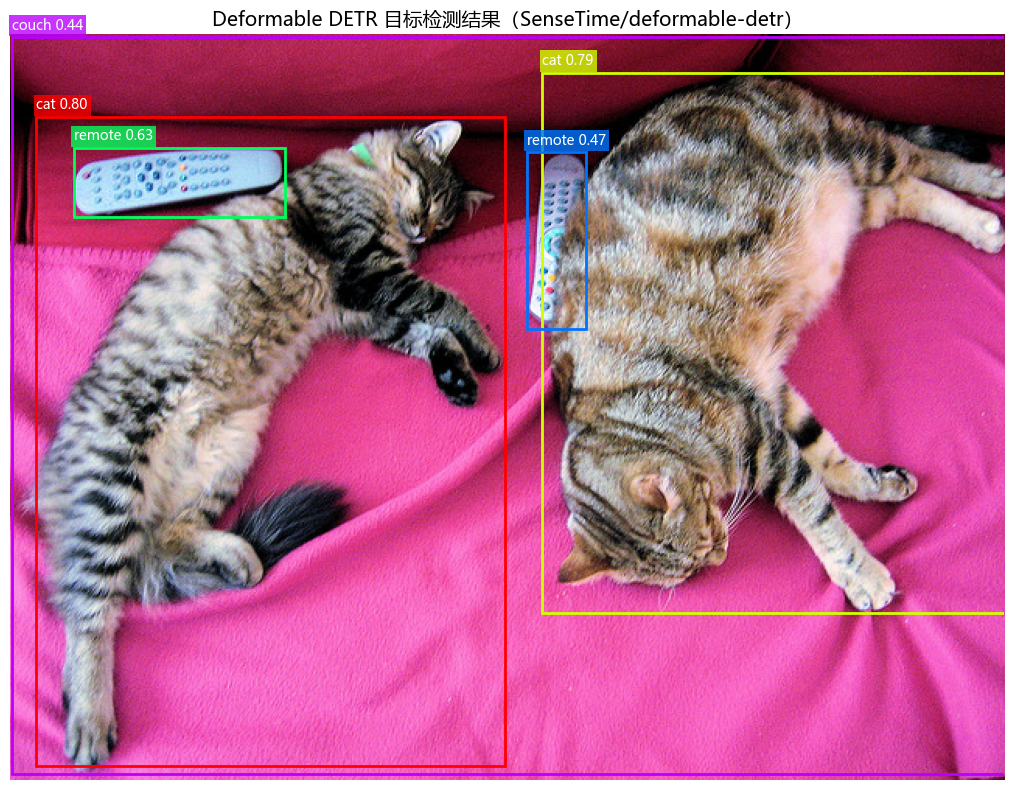

In [ ]:
# ─── 中文字体配置 ────────────────────────────────────────────────────────────────
# Matplotlib 默认字体 DejaVu Sans 不含 CJK 字形，在标题/标签中使用中文会出现方块或警告
# 在 Windows 上将字体切换为微软雅黑（Microsoft YaHei），该字体内置于系统，无需额外安装
# rcParams["font.sans-serif"]: List[str]，无衬线字体候选列表，Matplotlib 按顺序寻找可用字体
# rcParams["axes.unicode_minus"]: bool，设为 False 以避免负号被渲染为方块（与中文字体兼容问题）
import matplotlib
matplotlib.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]  # 优先微软雅黑
matplotlib.rcParams["axes.unicode_minus"] = False  # 正确显示坐标轴负号

# ─── 后处理：将模型输出转换为可读检测结果 ────────────────────────────────────────
# image.size[::-1]: PIL 的 size 为 (W, H)，翻转后得 (H, W)，满足 target_sizes 的顺序要求
# torch.tensor: 包装为形状 (1, 2) 的张量，对应 batch 第 0 张图的原始分辨率
target_sizes = torch.tensor([image.size[::-1]])  # 形状 (1, 2)，示例值 [480, 640]

# post_process_object_detection 内部流程：
#   1. 对 logits 做 softmax，得到 300 个 query × 92 类的概率分布
#   2. 取每个 query 置信度最高的类别及其分数
#   3. 过滤置信度 <= threshold 的 query（300 个中通常仅有极少数通过）
#   4. 将归一化框 (cx, cy, w, h) 转换为绝对像素坐标 (x1, y1, x2, y2)
# threshold=0.5: Deformable DETR 相比 DETR 精度更高，可用更低阈值；可根据需要调整
# 返回值: List[Dict]；每个 Dict 包含：
#   - "scores": Tensor，形状 (n_det,)，置信度，float32
#   - "labels": Tensor，形状 (n_det,)，COCO 类别 id，int64
#   - "boxes":  Tensor，形状 (n_det, 4)，绝对像素坐标 (x1, y1, x2, y2)，float32
results = processor.post_process_object_detection(
    outputs, target_sizes=target_sizes, threshold=0.4
)[0]  # 取 batch 第 0 张图的结果，类型 Dict[str, Tensor]

# ─── 控制台打印检测结果 ─────────────────────────────────────────────────────────
print(f"共检测到 {len(results['scores'])} 个目标（置信度阈值=0.4）：\n")
for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    # model.config.id2label: Dict[int, str]，COCO 类别 id → 类别名称字符串映射
    class_name = model.config.id2label[label.item()]        # label.item() 转为 Python int
    confidence = round(score.item(), 3)                     # score.item() 转为 Python float
    coords = [round(c, 1) for c in box.tolist()]           # box.tolist() 转为 [x1,y1,x2,y2]
    print(f"  {class_name:<15} 置信度: {confidence:<6}  框: {coords}")

# ─── 可视化：在原图上绘制检测框与标签 ────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(12, 8))  # 创建 12×8 英寸画布，ax 为 Axes 对象
ax.imshow(image)                                # 将 PIL 图像渲染到坐标轴（自动解析 RGB 通道）

# 使用 plt.cm.hsv 色彩映射为不同类别分配不同颜色
# len(results["scores"]): int，检测到的目标数量
n_det = len(results["scores"])
colors = plt.cm.hsv([i / max(n_det, 1) for i in range(n_det)])  # List，每个元素为 RGBA 颜色元组

for idx, (score, label, box) in enumerate(
    zip(results["scores"], results["labels"], results["boxes"])
):
    x1, y1, x2, y2 = box.tolist()              # 解包四个角点坐标（绝对像素值，float）
    box_w = x2 - x1                             # 边界框宽度（像素）
    box_h = y2 - y1                             # 边界框高度（像素）
    class_name = model.config.id2label[label.item()]  # str，COCO 类别名称
    color = colors[idx]                         # 当前目标对应的 RGBA 颜色元组

    # patches.Rectangle: 创建矩形边界框 patch
    # (x1, y1): 左上角坐标；box_w/box_h: 宽高；linewidth=2: 边框宽度
    # edgecolor=color: 使用该目标专属颜色；facecolor="none": 透明填充
    rect = patches.Rectangle(
        (x1, y1), box_w, box_h,
        linewidth=2, edgecolor=color, facecolor="none"
    )
    ax.add_patch(rect)   # 将矩形 patch 注册到 Axes

    # ax.text: 在框左上角绘制类别名称 + 置信度标签
    # bbox.facecolor=color: 标签背景使用与边框相同的颜色，便于区分不同目标
    ax.text(
        x1, y1 - 5,
        f"{class_name} {score:.2f}",
        fontsize=10, color="white",
        bbox=dict(facecolor=color, alpha=0.8, pad=2, edgecolor="none")
    )

ax.axis("off")                                                               # 隐藏坐标轴刻度与边框
plt.title("Deformable DETR 目标检测结果（SenseTime/deformable-detr）", fontsize=14)  # 图标题
plt.tight_layout()                                                           # 自动调整布局间距
plt.show()                                                                   # 渲染并显示